# 07 — Viterbi vs filtered timeline

Side-by-side HMM regime paths on full-sample std: **global Viterbi** (look-ahead) versus **forward-filtered** (causal) decode, with NBER recession shading.

The two paths agree on most weeks; filtered decoding inserts extra boundary switches that shorten regime runs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from regime_utils import *

In [2]:
std = load_full_sample_std()
X = std.values
raw_fit = load_raw_features().loc[std.index]

hmm = fit_hmm(X)
vit_int = viterbi_decode(hmm, X)
filt_int = filtered_decode(hmm, X)

vit_labels = build_regime_frame(raw_fit, vit_int, "Regime_HMM")["Regime_label"]
filt_labels = build_regime_frame(raw_fit, filt_int, "Regime_HMM_filtered")["Regime_label"]
dates = std.index

n_diff = (vit_labels != filt_labels).sum()
vit_switches = int((np.diff(vit_int) != 0).sum())
filt_switches = int((np.diff(filt_int) != 0).sum())

print(f"Named-label agreement: {len(dates) - n_diff} / {len(dates)} weeks ({1 - n_diff / len(dates):.1%})")
print(f"Boundary switches — Viterbi: {vit_switches}, filtered: {filt_switches}")
print(f"Mean run length — Viterbi: {run_length_mean(vit_int):.1f} wk, filtered: {run_length_mean(filt_int):.1f} wk")

Named-label agreement: 1513 / 1564 weeks (96.7%)
Boundary switches — Viterbi: 27, filtered: 37
Mean run length — Viterbi: 55.9 wk, filtered: 41.2 wk


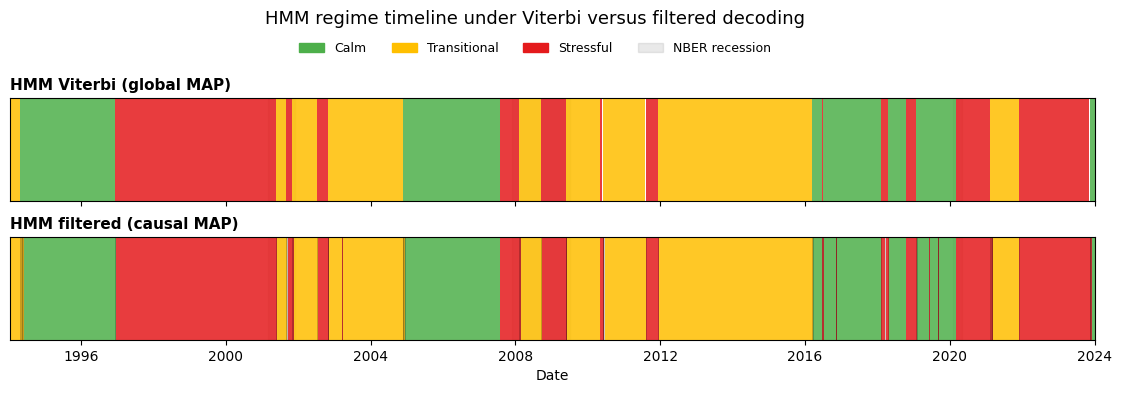

In [3]:
REGIME_COLORS = {
    CALM_LABEL: "#4daf4a",
    TRANSITIONAL_LABEL: "#ffbf00",
    STRESS_LABEL: "#e41a1c",
}


def add_nber_shading(ax):
    for start, end, _ in NBER_RECESSIONS:
        ax.axvspan(
            pd.Timestamp(start),
            pd.Timestamp(end),
            color="#888888",
            alpha=0.18,
            zorder=0,
        )


def regime_runs(index, labels):
    idx = pd.Index(index)
    labs = pd.Series(labels, index=idx)
    runs = []
    start_i = 0
    for i in range(1, len(labs)):
        if labs.iloc[i] != labs.iloc[start_i]:
            runs.append((idx[start_i], idx[i - 1], labs.iloc[start_i]))
            start_i = i
    runs.append((idx[start_i], idx[-1], labs.iloc[start_i]))
    return runs


def plot_regime_timeline(ax, index, labels, title):
    add_nber_shading(ax)
    idx = pd.Index(index)
    for start, end, label in regime_runs(idx, labels):
        ax.axvspan(
            start,
            end + pd.Timedelta(days=6),
            color=REGIME_COLORS[label],
            alpha=0.85,
            linewidth=0,
            zorder=1,
        )
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlim(idx.min(), idx.max() + pd.Timedelta(days=6))


fig, axes = plt.subplots(2, 1, figsize=(14, 3.4), sharex=True)
plot_regime_timeline(axes[0], dates, vit_labels, "HMM Viterbi (global MAP)")
plot_regime_timeline(axes[1], dates, filt_labels, "HMM filtered (causal MAP)")

disagree = vit_labels.values != filt_labels.values
for d in dates[disagree]:
    axes[1].axvline(d, color="black", alpha=0.25, linewidth=0.6, zorder=2)

legend_patches = [
    mpatches.Patch(color=REGIME_COLORS[l], label=l)
    for l in [CALM_LABEL, TRANSITIONAL_LABEL, STRESS_LABEL]
]
legend_patches.append(mpatches.Patch(color="#888888", alpha=0.18, label="NBER recession"))
fig.legend(
    handles=legend_patches,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
    fontsize=9,
)
axes[1].set_xlabel("Date")
fig.suptitle(
    "HMM regime timeline under Viterbi versus filtered decoding",
    y=1.08,
    fontsize=13,
)
fig.subplots_adjust(top=0.82, hspace=0.35)
plt.show()

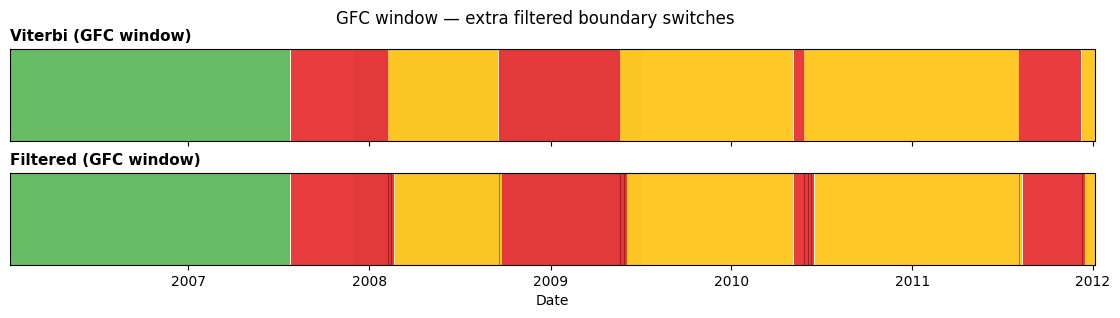

In [ ]:
# Zoom: GFC — filtered path inserts short runs inside Viterbi's regime spans
zoom_start, zoom_end = "2006-01-01", "2011-12-31"
mask = (dates >= zoom_start) & (dates <= zoom_end)
zoom_dates = dates[mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 2.8), sharex=True)
plot_regime_timeline(axes[0], zoom_dates, vit_labels.loc[mask], "Viterbi (GFC window)")
plot_regime_timeline(axes[1], zoom_dates, filt_labels.loc[mask], "Filtered (GFC window)")

for d in zoom_dates[disagree[mask]]:
    axes[1].axvline(d, color="black", alpha=0.35, linewidth=0.8, zorder=2)

axes[1].set_xlabel("Date")
fig.suptitle("GFC window — extra filtered boundary switches", y=1.02, fontsize=12)
fig.subplots_adjust(hspace=0.35)
plt.show()